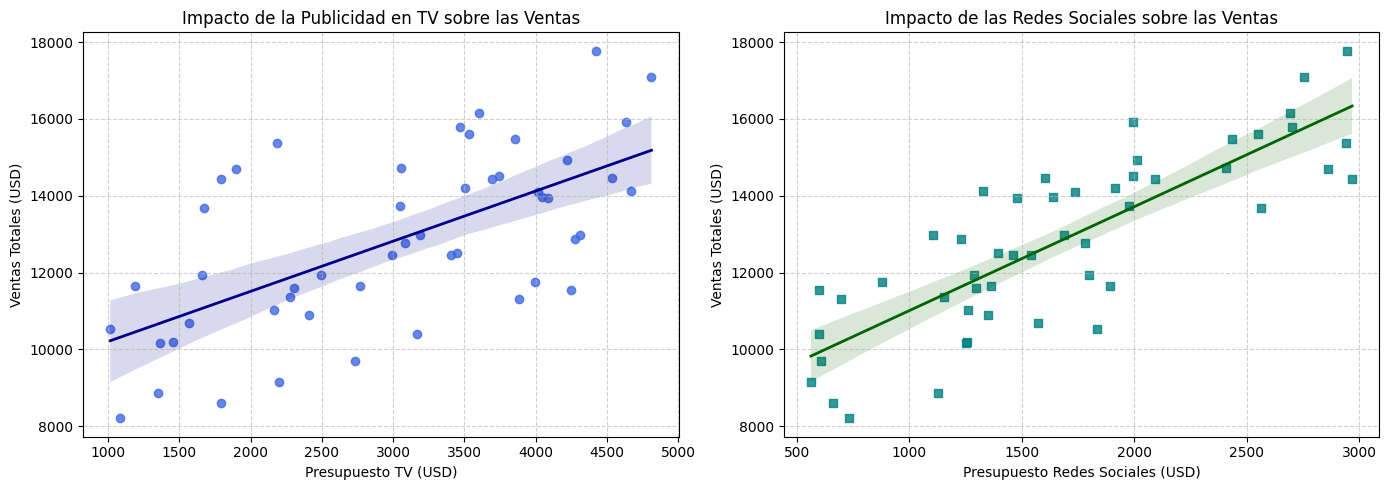

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# 1. Simulación de datos (50 meses de campañas publicitarias)
np.random.seed(10)
meses = 50

gasto_tv = np.random.uniform(1000, 5000, meses)       # Inversión en TV entre $1000 y $5000
gasto_redes = np.random.uniform(500, 3000, meses)     # Inversión en Redes entre $500 y $3000

# Ventas base de 5000 + impacto de TV (x1.2) + impacto de Redes (x2.5) + ruido aleatorio
ventas = 5000 + (gasto_tv * 1.2) + (gasto_redes * 2.5) + np.random.normal(0, 300, meses)

# Crear el DataFrame de trabajo
df = pd.DataFrame({'TV': gasto_tv, 'Redes': gasto_redes, 'Ventas': ventas})

# 2. Entrenar el modelo de Regresión Lineal Múltiple
X = df[['TV', 'Redes']]
y = df['Ventas']
modelo = LinearRegression()
modelo.fit(X, y)

# ==========================================
# GRÁFICO 1: Análisis Individual (2D con Línea de Tendencia)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico para televisión
sns.regplot(ax=axes[0], x='TV', y='Ventas', data=df, color='royalblue', marker='o',
            line_kws={'color': 'darkblue', 'linewidth': 2})
axes[0].set_title('Impacto de la Publicidad en TV sobre las Ventas')
axes[0].set_xlabel('Presupuesto TV (USD)')
axes[0].set_ylabel('Ventas Totales (USD)')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Gráfico para redes sociales
sns.regplot(ax=axes[1], x='Redes', y='Ventas', data=df, color='seagreen', marker='s',
            line_kws={'color': 'darkgreen', 'linewidth': 2}, scatter_kws={'color': 'teal'})
axes[1].set_title('Impacto de las Redes Sociales sobre las Ventas')
axes[1].set_xlabel('Presupuesto Redes Sociales (USD)')
axes[1].set_ylabel('Ventas Totales (USD)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


=== REPORTE DE CLASIFICACIÓN MULTICLASE ===
                 precision    recall  f1-score   support

    Alto Riesgo       1.00      1.00      1.00        14
    Bajo Riesgo       1.00      1.00      1.00         4
Riesgo Moderado       1.00      1.00      1.00        12

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



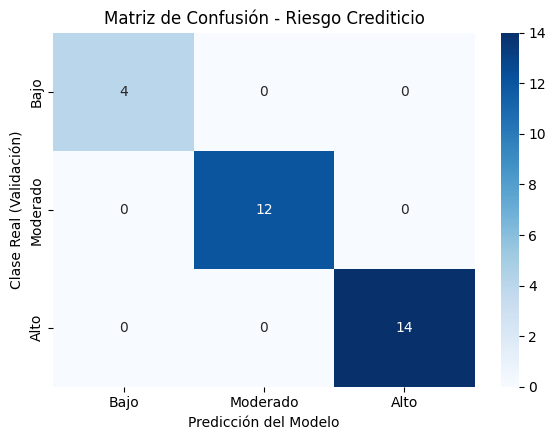

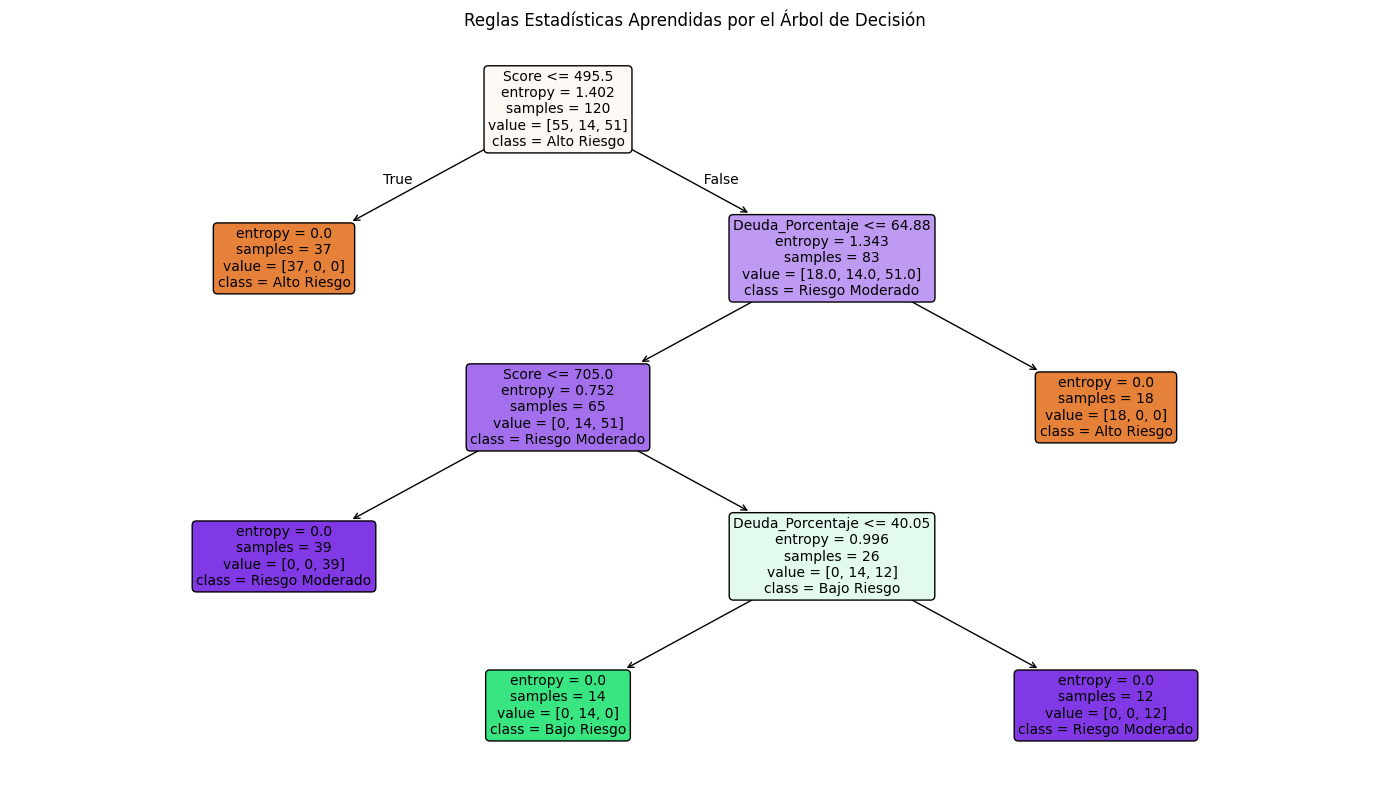

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. Simulación del Dataset Bancario (150 clientes)
np.random.seed(42)
n_clientes = 150

score_crediticio = np.random.randint(300, 850, n_clientes)  # Score de 300 a 850
ingresos_miles = np.random.uniform(1.2, 8.0, n_clientes)    # Ingresos mensuales de $1.2k a $8.0k
deuda_porcentaje = np.random.uniform(10, 80, n_clientes)    # Porcentaje de ingresos destinado a deudas

# Lógica condicional simulada para asignar las 3 categorías (Bajo, Moderado, Alto Riesgo)
riesgo = []
for idx in range(n_clientes):
    if score_crediticio[idx] > 700 and deuda_porcentaje[idx] < 40:
        riesgo.append('Bajo Riesgo')
    elif score_crediticio[idx] < 500 or deuda_porcentaje[idx] > 65:
        riesgo.append('Alto Riesgo')
    else:
        riesgo.append('Riesgo Moderado')

df = pd.DataFrame({
    'Score': score_crediticio,
    'Ingresos': ingresos_miles,
    'Deuda_Porcentaje': deuda_porcentaje,
    'Riesgo': riesgo
})

# 2. Configuración de Variables (Características vs Objetivo Multiclase)
X = df[['Score', 'Ingresos', 'Deuda_Porcentaje']]
y = df['Riesgo']

# Hiperparámetro de flujo: Split de datos (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Creación del Modelo con Hiperparámetros de Control (Pre-poda para evitar Overfitting)
modelo_arbol = DecisionTreeClassifier(
    criterion='entropy',    # Mide la pureza de la división (Ganancia de información)
    max_depth=4,            # Límite de niveles de profundidad del árbol
    random_state=42
)

# Entrenamiento
modelo_arbol.fit(X_train, y_train)

# 4. Predicciones y Evaluación Estadísticas
y_pred = modelo_arbol.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN MULTICLASE ===")
print(classification_report(y_test, y_pred))

# ==========================================
# VISUALIZACIÓN 1: Matriz de Confusión
# ==========================================
plt.figure(figsize=(6, 4.5))
cm = confusion_matrix(y_test, y_pred, labels=['Bajo Riesgo', 'Riesgo Moderado', 'Alto Riesgo'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Bajo', 'Moderado', 'Alto'], 
            yticklabels=['Bajo', 'Moderado', 'Alto'])
plt.title('Matriz de Confusión - Riesgo Crediticio')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Clase Real (Validación)')
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZACIÓN 2: Estructura del Árbol de Decisión
# ==========================================
plt.figure(figsize=(14, 8))
plot_tree(modelo_arbol, 
          feature_names=['Score', 'Ingresos', 'Deuda_Porcentaje'], 
          class_names=['Alto Riesgo', 'Bajo Riesgo', 'Riesgo Moderado'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Reglas Estadísticas Aprendidas por el Árbol de Decisión')
plt.tight_layout()
plt.show()